# Import  Libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df = pd.read_csv(r"E:\ML_learn\netflix_titles\netflix_titles.csv")

In [37]:
# Display first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [38]:
# Shape of dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (8807, 12)


In [39]:
# Column names
print("Columns:", df.columns)

Columns: Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [40]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [41]:
# Statistical summary
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000



# Missing Value Analysis

In [42]:
# Check missing values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

# Data Cleaning
## Fill missing values with meaningful placeholders

In [43]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

In [44]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

# Convert Date Column

In [ ]:
# Convert date_added to datetime

In [45]:
# df['date_added'] = pd.to_datetime(df['date_added'])
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')


In [46]:
# Extract year from date_added
df['year_added'] = df['date_added'].dt.year

# Exploratory Data Analysis (EDA)
Movies vs TV Shows

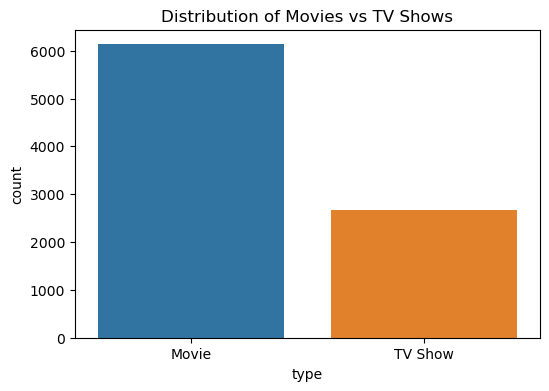

In [47]:
# Movies dominate Netflix content compared to TV Shows.
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Distribution of Movies vs TV Shows")
plt.show()



In [ ]:
# Top 10 Countries with most content

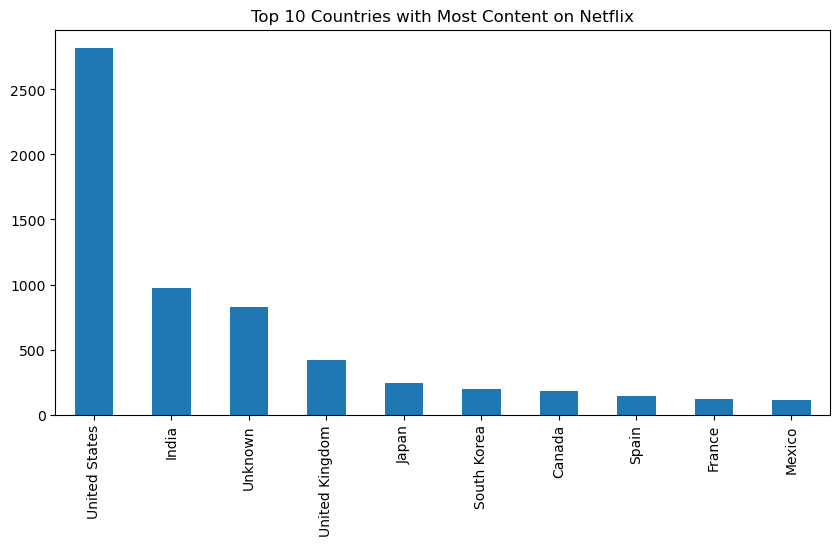

In [49]:
# The United States produces the highest number of titles on Netflix.
plt.figure(figsize=(10,5))
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries with Most Content on Netflix")
plt.show()

In [ ]:
# Rating Distribution

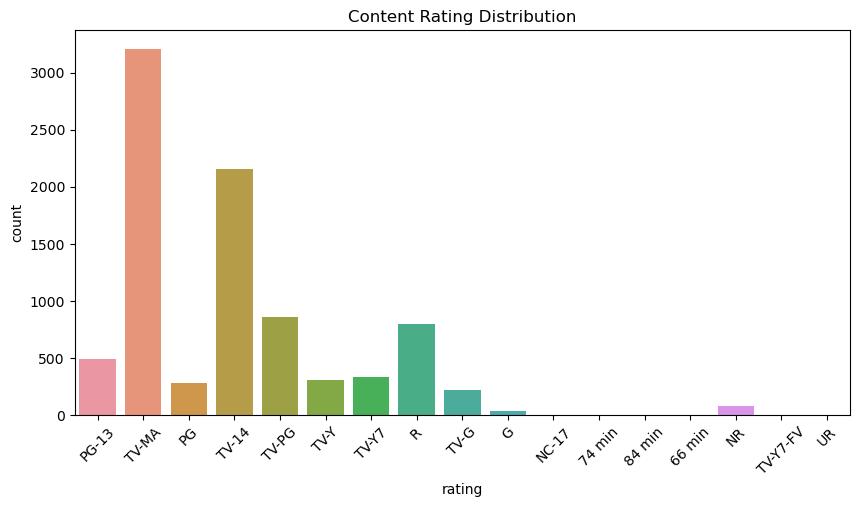

In [80]:
# TV-MA and TV-14 are the most common content ratings on Netflix.
plt.figure(figsize=(10,5))
sns.countplot(x='rating', data=df)
plt.title("Content Rating Distribution")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Release Year Distribution

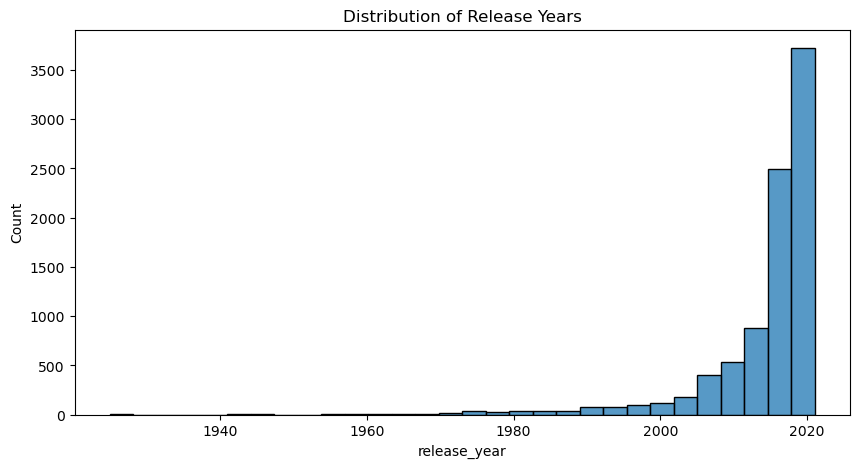

In [81]:
# Most Netflix titles were released after 2010.
plt.figure(figsize=(10,5))
sns.histplot(df['release_year'], bins=30)
plt.title("Distribution of Release Years")
plt.show()

In [ ]:
# Content Added Per Year

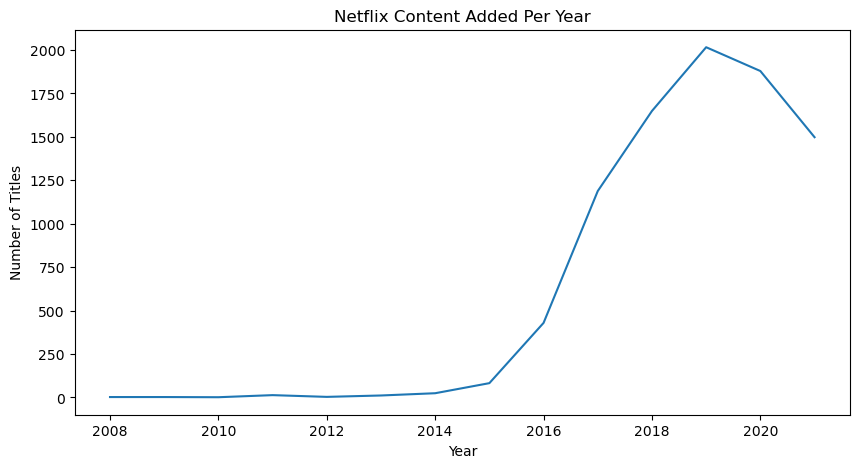

In [82]:
# Netflix significantly increased the amount of content added after 2016.
plt.figure(figsize=(10,5))
df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Netflix Content Added Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

In [ ]:
# Top 10 Genres

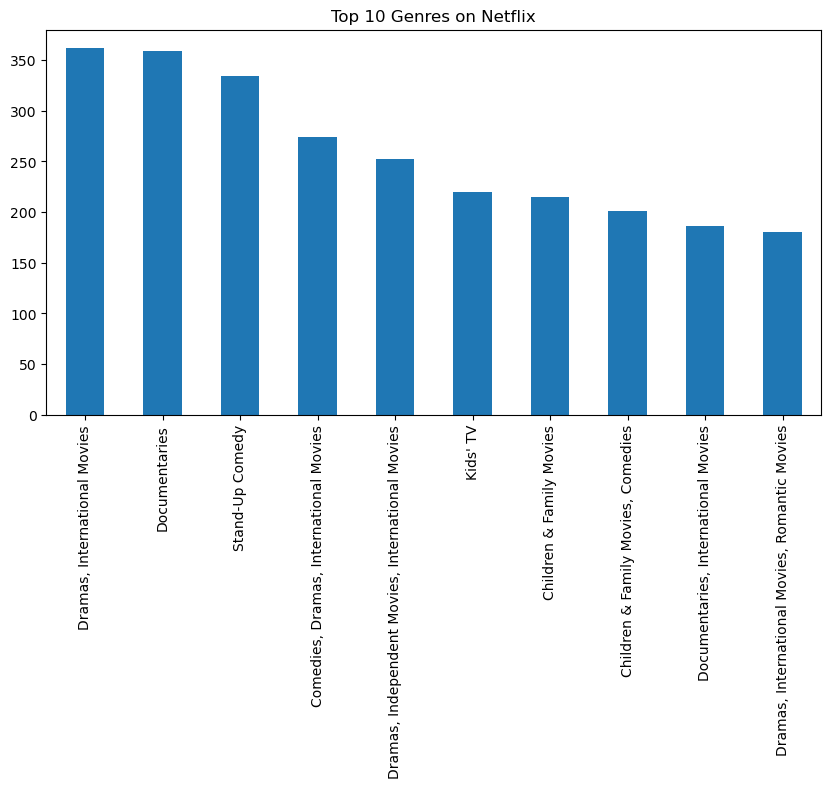

In [83]:
# Drama and International TV Shows are among the most common genres on Netflix.
plt.figure(figsize=(10,5))
df['listed_in'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Genres on Netflix")
plt.show()

In [55]:
print("Key Insights:")
print("1. Movies dominate Netflix content compared to TV Shows.")
print("2. United States contributes the largest amount of content.")
print("3. Most Netflix content was added after 2016.")
print("4. TV-MA and TV-14 are the most common content ratings.")
print("5. Drama and International TV Shows are among the most common genres.")

Key Insights:
1. Movies dominate Netflix content compared to TV Shows.
2. United States contributes the largest amount of content.
3. Most Netflix content was added after 2016.
4. TV-MA and TV-14 are the most common content ratings.
5. Drama and International TV Shows are among the most common genres.
